# Complexity threshold analysis

Pick a principled complexity threshold from the per-degree spherical-harmonic
reconstruction error (`complexity_errors`, already saved in `Data/master.npz`)
instead of relying on the single hardcoded `L_CROSS_THRESHOLD = 0.015`.

In [17]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

ROOT = '.'
COMPLEXITY_LMAX = 9            # matches compute_master_npz.COMPLEXITY_LMAX (number of error columns)
DEFAULT_THRESHOLD = 0.005    # matches compute_master_npz.L_CROSS_THRESHOLD
ls = np.arange(COMPLEXITY_LMAX)          # lmax axis: 0..8 (col i = recon incl. SH degrees 0..i)

master = np.load(f'{ROOT}/Data/npz/master.npz', allow_pickle=True)
errors    = master['complexity_errors'].astype(float)   # (N, 9) accumulated, area-normalized RMSE
ids       = master['ids']
datasets  = master['datasets']
times     = master['times']
areas     = master['areas']
l_cross_saved = master['l_cross_values'].astype(float)
N = len(ids)
print('organoids:', N, '| errors shape:', errors.shape)


def l_cross_from_errors(errs2d, threshold, lmax=COMPLEXITY_LMAX):
    """Interpolated lmax (max SH degree) where the accumulated recon error crosses `threshold`.
    Vectorized form of compute_master_npz.compute_l_cross over a (N, lmax) array.
    Column i is the reconstruction including SH degrees 0..i (i.e. lmax=i). If the finest
    error (lmax = lmax-1) is still above threshold -> never crosses -> lmax-1."""
    errs2d = np.asarray(errs2d, float)
    lmax_max = lmax - 1
    xp = np.arange(lmax_max, -1, -1)     # degrees descending: lmax_max..0
    out = np.empty(errs2d.shape[0])
    for i, errs in enumerate(errs2d):
        if errs[-1] > threshold:
            out[i] = float(lmax_max)
        else:
            out[i] = float(np.interp(threshold, errs[::-1], xp))
    return out


# Sanity: replicated interpolation reproduces the pipeline's l_cross at the default threshold.
l_cross_repro = l_cross_from_errors(errors, DEFAULT_THRESHOLD)
assert np.allclose(l_cross_repro, l_cross_saved, atol=1e-6), 'l_cross mismatch vs master'

# Sanity: error should be (almost) non-increasing with degree.
non_incr_frac = np.mean(np.all(np.diff(errors, axis=1) <= 1e-9, axis=1))
print(f'rows with monotonically non-increasing error: {non_incr_frac:.3%}')
print('l_cross_from_errors reproduces master l_cross_values: OK')

organoids: 3053 | errors shape: (3053, 9)


AssertionError: l_cross mismatch vs master

## Per-degree reconstruction error distribution

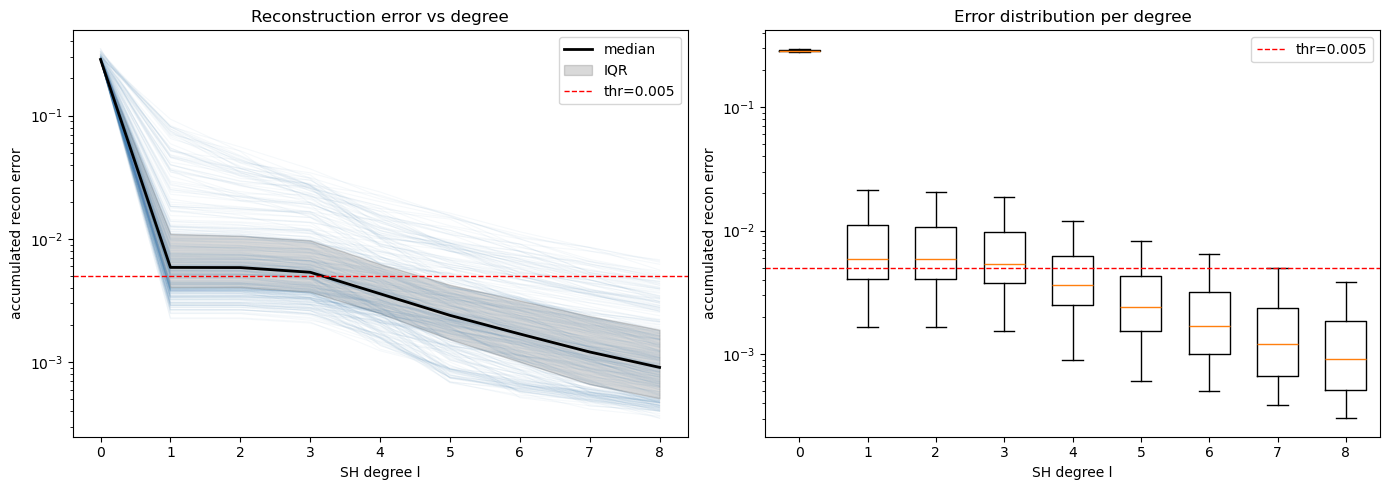

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) error-decay curves: sampled organoids + median/IQR band
rng = np.random.default_rng(0)
sample = rng.choice(N, size=min(300, N), replace=False)
for i in sample:
    axes[0].plot(ls, errors[i], color='steelblue', alpha=0.05, lw=0.8)
med = np.median(errors, axis=0)
q1, q3 = np.percentile(errors, [25, 75], axis=0)
axes[0].plot(ls, med, color='black', lw=2, label='median')
axes[0].fill_between(ls, q1, q3, color='black', alpha=0.15, label='IQR')
axes[0].axhline(DEFAULT_THRESHOLD, color='red', ls='--', lw=1, label=f'thr={DEFAULT_THRESHOLD}')
axes[0].set(xlabel='SH degree l', ylabel='accumulated recon error', yscale='log',
            title='Reconstruction error vs degree')
axes[0].set_xticks(ls)
axes[0].legend()

# (b) per-degree distribution
axes[1].boxplot([errors[:, k] for k in range(COMPLEXITY_LMAX)], positions=ls,
                widths=0.6, showfliers=False)
axes[1].axhline(DEFAULT_THRESHOLD, color='red', ls='--', lw=1, label=f'thr={DEFAULT_THRESHOLD}')
axes[1].set(xlabel='SH degree l', ylabel='accumulated recon error', yscale='log',
            title='Error distribution per degree')
axes[1].legend()
plt.tight_layout()
plt.show()

## Compare against sphericity

Spheres should reconstruct with very low error at low degree, so high sphericity
should track with low low-degree error and low l_cross.

sphericity coverage: 100.000% (3053/3053)


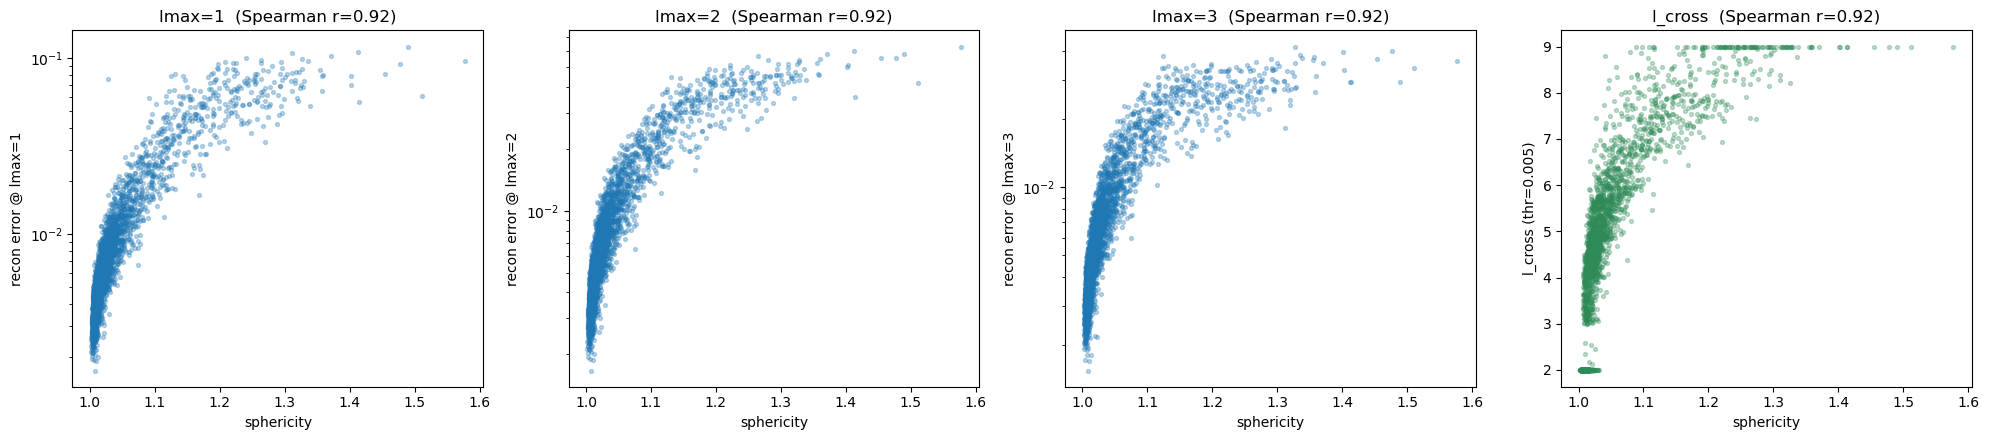

In [19]:
def load_sphericity(ids, datasets, root=ROOT):
    """Sphericity aligned row-wise to `ids` (NaN where missing).
    Mirrors dim_red.load_mesh_features: per-dataset CSV indexed by label_uid,
    bare uid = id without the '{dataset}_' prefix."""
    tabs = {}
    for d in sorted(set(datasets)):
        p = f'{root}/Data/{d}/feature_tables/mesh_features.csv'
        tabs[d] = pd.read_csv(p).set_index('label_uid')
    out = np.full(len(ids), np.nan)
    for i, (u, d) in enumerate(zip(ids, datasets)):
        bare = u[len(d) + 1:]
        if d in tabs and bare in tabs[d].index:
            val = tabs[d].loc[bare, 'sphericity']
            out[i] = float(val if np.ndim(val) == 0 else np.asarray(val).ravel()[0])
    return out


sphericity = load_sphericity(ids, datasets)
ok = np.isfinite(sphericity)
print(f'sphericity coverage: {ok.mean():.3%} ({ok.sum()}/{N})')

low_degrees = [1, 2, 3]   # lmax values (recon incl. SH degrees 0..lmax)
fig, axes = plt.subplots(1, len(low_degrees) + 1, figsize=(5 * (len(low_degrees) + 1), 4.5))
for ax, l in zip(axes[:-1], low_degrees):
    y = errors[:, l]
    ax.scatter(sphericity[ok], y[ok], s=8, alpha=0.3)
    r = spearmanr(sphericity[ok], y[ok]).correlation
    ax.set(xlabel='sphericity', ylabel=f'recon error @ lmax={l}', yscale='log',
           title=f'lmax={l}  (Spearman r={r:.2f})')
# vs l_cross at default threshold
r = spearmanr(sphericity[ok], l_cross_saved[ok]).correlation
axes[-1].scatter(sphericity[ok], l_cross_saved[ok], s=8, alpha=0.3, color='seagreen')
axes[-1].set(xlabel='sphericity', ylabel=f'l_cross (thr={DEFAULT_THRESHOLD})',
             title=f'l_cross  (Spearman r={r:.2f})')
plt.tight_layout()
plt.show()

## Explore thresholds -> l_cross distribution

Pick a threshold where l_cross is informative: not collapsed near 0 (lmax floor), and not
saturated at lmax-1 = 8 (shapes that never cross).

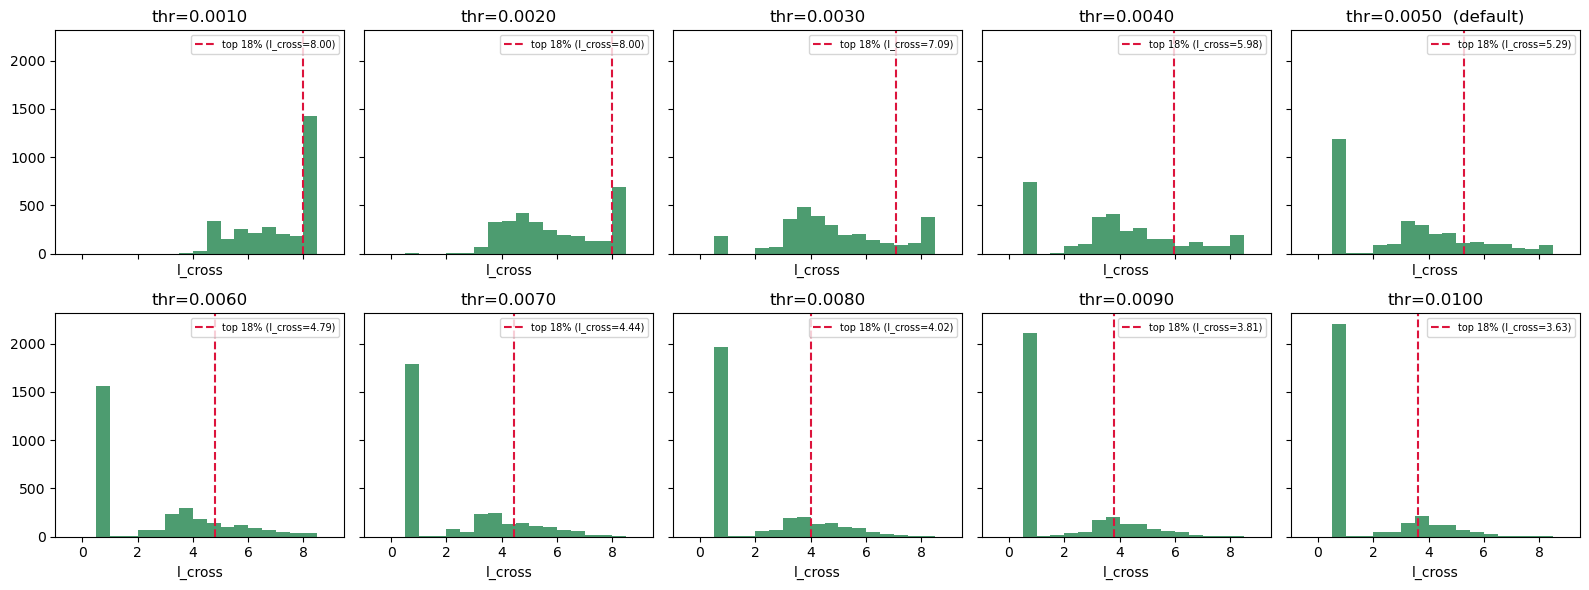

CHOSEN_THRESHOLD = 0.005


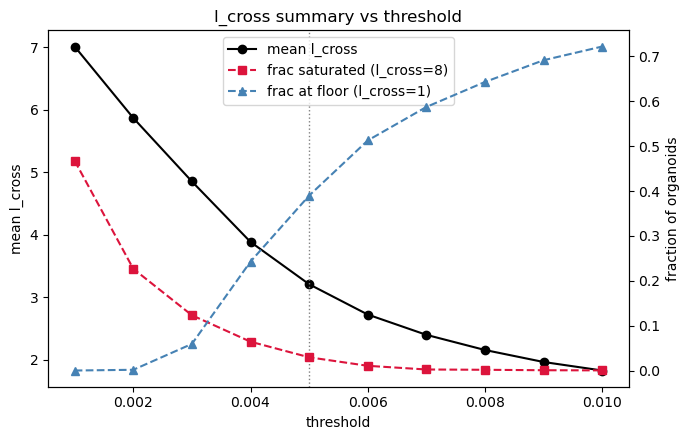

In [20]:
thresholds = np.linspace(0.001, 0.01, 10)   
l_cross_by_thr = {t: l_cross_from_errors(errors, t) for t in thresholds}

TOP_FRAC = 0.18   # mark the cutoff for the most-complex 20% of organoids

# Small-multiples of l_cross histograms, with a line at the top-20% cutoff (80th pctile)
ncol = 5
nrow = int(np.ceil(len(thresholds) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3 * nrow), sharex=True, sharey=True)
bins = np.arange(-0.5, COMPLEXITY_LMAX + 0.5, 0.5)   # l_cross now spans lmax 0..8
for ax, t in zip(axes.ravel(), thresholds):
    lc = l_cross_by_thr[t]
    cut = np.quantile(lc, 1 - TOP_FRAC)   # l_cross value above which the top 20% sit
    ax.hist(lc, bins=bins, color='seagreen', alpha=0.85)
    ax.axvline(cut, color='crimson', ls='--', lw=1.5,
               label=f'top {TOP_FRAC:.0%} (l_cross={cut:.2f})')
    ax.set_title(f'thr={t:.4f}' + ('  (default)' if np.isclose(t, DEFAULT_THRESHOLD) else ''))
    ax.set_xlabel('l_cross')
    ax.legend(fontsize=7, loc='upper right')
for ax in axes.ravel()[len(thresholds):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Choose a threshold for the dim-red overlay (edit after inspecting the plots).
CHOSEN_THRESHOLD = 0.005
print('CHOSEN_THRESHOLD =', CHOSEN_THRESHOLD)

# Summary curves vs threshold
mean_lc = np.array([l_cross_by_thr[t].mean() for t in thresholds])
sat_frac = np.array([(l_cross_by_thr[t] >= COMPLEXITY_LMAX - 1).mean() for t in thresholds])
floor_frac = np.array([(l_cross_by_thr[t] <= 1.0 + 1e-9).mean() for t in thresholds])
fig, ax = plt.subplots(figsize=(7, 4.5))
h = []
h += ax.plot(thresholds, mean_lc, 'o-', color='black', label='mean l_cross')
ax.set(xlabel='threshold', ylabel='mean l_cross')
ax.axvline(CHOSEN_THRESHOLD, color='gray', ls=':', lw=1)
ax2 = ax.twinx()
h += ax2.plot(thresholds, sat_frac, 's--', color='crimson', label=f'frac saturated (l_cross={COMPLEXITY_LMAX - 1})')
h += ax2.plot(thresholds, floor_frac, '^--', color='steelblue', label='frac at floor (l_cross=1)')
ax2.set_ylabel('fraction of organoids')
ax.legend(h, [a.get_label() for a in h], loc='upper center')
ax.set_title('l_cross summary vs threshold')
plt.tight_layout()
plt.show()

## Visualize complexity on the shape dim-red

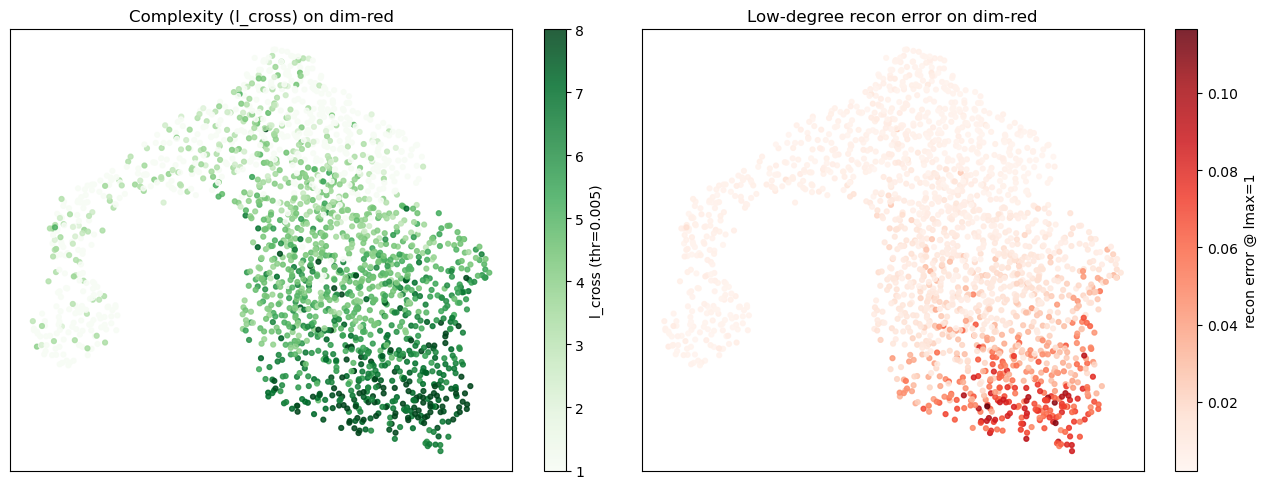

In [21]:
emb = np.load(f'{ROOT}/Data/embeddings/hks_emb.npz', allow_pickle=True)
xy = emb['xy']
emb_ids = emb['ids']

# Align complexity (master) -> embedding subset by uid
pos = {u: i for i, u in enumerate(ids)}
missing = [u for u in emb_ids if u not in pos]
assert not missing, f'{len(missing)} embedding ids absent from master (e.g. {missing[:3]})'
idx = np.array([pos[u] for u in emb_ids])

l_cross_chosen = l_cross_from_errors(errors, CHOSEN_THRESHOLD)
emb_complexity = l_cross_chosen[idx]
emb_err_l1 = errors[idx, 1]   # raw recon error at lmax=1 (degrees 0..1)

point_size = 12
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc0 = axes[0].scatter(xy[:, 0], xy[:, 1], c=emb_complexity, cmap='Greens',
                      s=point_size, alpha=0.85)
fig.colorbar(sc0, ax=axes[0]).set_label(f'l_cross (thr={CHOSEN_THRESHOLD})')
axes[0].set_title('Complexity (l_cross) on dim-red')

sc1 = axes[1].scatter(xy[:, 0], xy[:, 1], c=emb_err_l1, cmap='Reds',
                      s=point_size, alpha=0.85)
fig.colorbar(sc1, ax=axes[1]).set_label('recon error @ lmax=1')
axes[1].set_title('Low-degree recon error on dim-red')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()